In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving abalone.csv to abalone.csv


In [3]:
abalone=pd.read_csv("abalone.csv")

In [4]:
abalone.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [5]:
abalone.tail()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4176,M,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12


In [6]:
abalone.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [7]:
abalone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [8]:
abalone.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'Rings'],
      dtype='object')

Text(0.5, 1.0, 'Missing Value Heatmap')

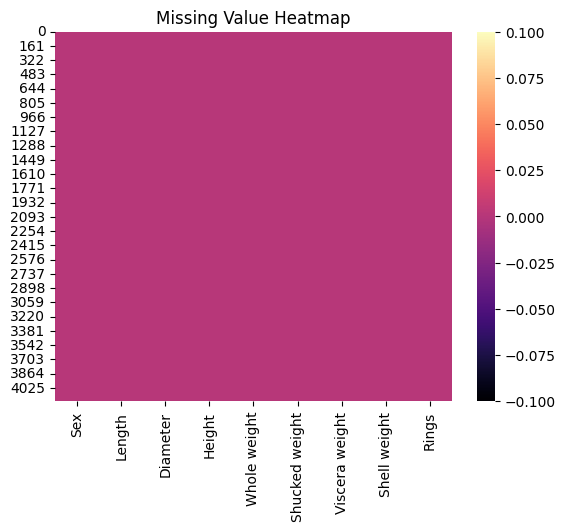

In [9]:
sns.heatmap(abalone.isnull(),cmap='magma')
plt.title("Missing Value Heatmap")

In [10]:
abalone.isnull()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
4172,False,False,False,False,False,False,False,False,False
4173,False,False,False,False,False,False,False,False,False
4174,False,False,False,False,False,False,False,False,False
4175,False,False,False,False,False,False,False,False,False


In [11]:
abalone.duplicated().sum()

np.int64(0)

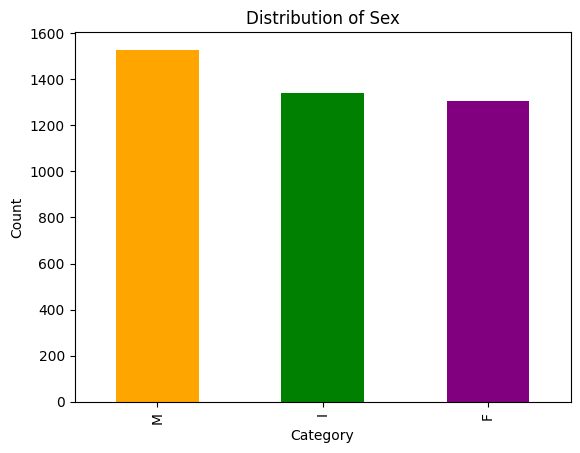

In [12]:
abalone['Sex'].value_counts().plot(kind='bar',color=['orange','green','purple'])
plt.title("Distribution of Sex")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

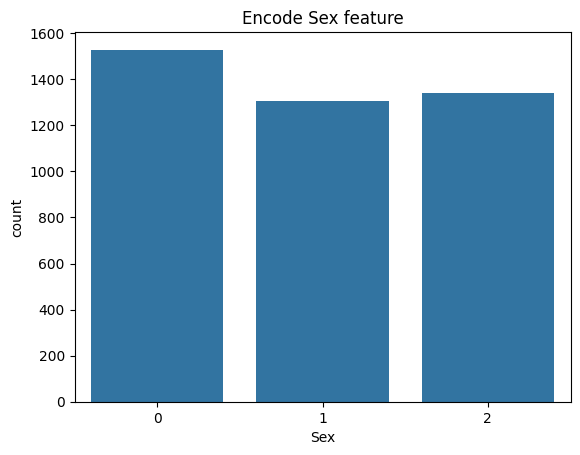

In [13]:
abalone['Sex'] = abalone['Sex'].map({'M': 0, 'F': 1, 'I': 2})
sns.countplot(x='Sex', data=abalone)
plt.title('Encode Sex feature')
plt.show()

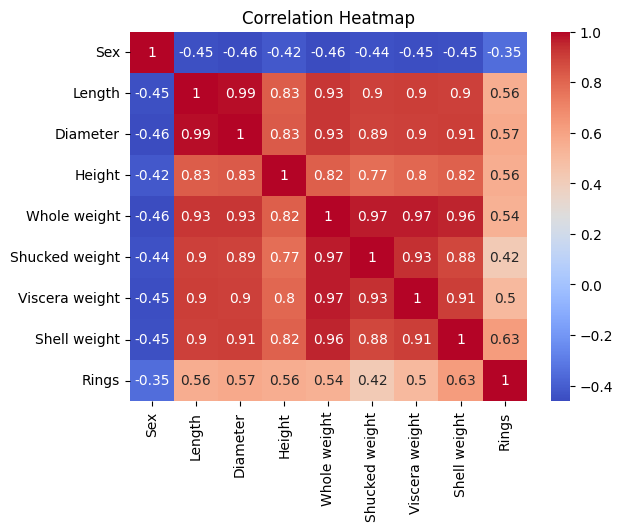

In [14]:
corr = abalone.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

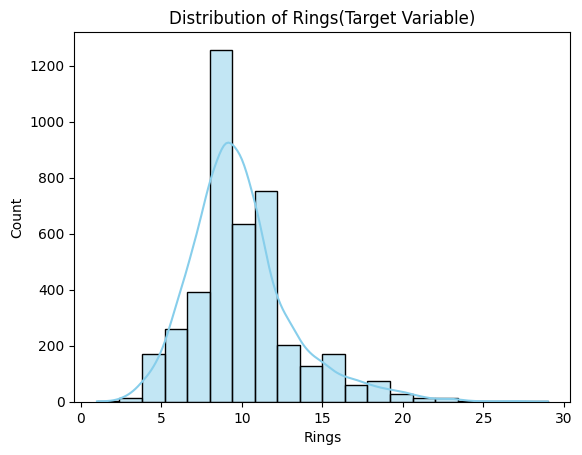

In [15]:
sns.histplot(abalone['Rings'], bins=20, kde=True, color="skyblue" )
plt.title('Distribution of Rings(Target Variable)')
plt.show()

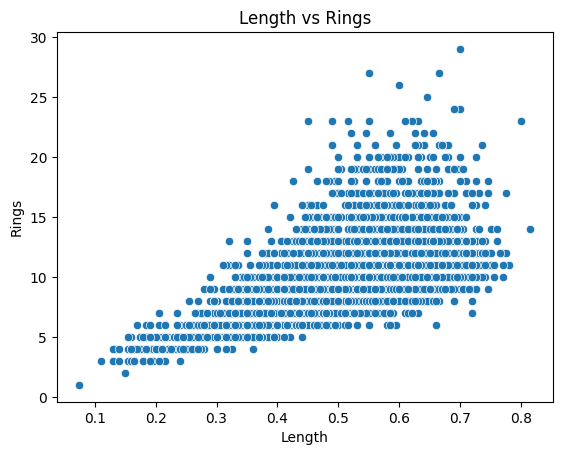

In [16]:
sns.scatterplot(x='Length',y='Rings',data=abalone)
plt.title('Length vs Rings')
plt.show()

SPLITING DATA SET


In [20]:
from sklearn.model_selection import train_test_split
X = abalone.drop('Rings',axis=1)
Y = abalone['Rings']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

FEATURE SCALLING
(standardization bring all feature to similar scale which is crucial for gradient based models like linear regression)


In [22]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


APPLYING MANY REGRESSION MODEL



In [25]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42))
]

results = {}
for name, model in models:
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(Y_test, y_pred)
    r2 = r2_score(Y_test, y_pred)
    results[name] = r2
    print(f'{name}: MSE = {mse:.2f}, R2 = {r2:.2f}')

Linear Regression: MSE = 4.95, R2 = 0.54
Ridge Regression: MSE = 4.95, R2 = 0.54
Decision Tree: MSE = 8.94, R2 = 0.17
Random Forest: MSE = 5.07, R2 = 0.53


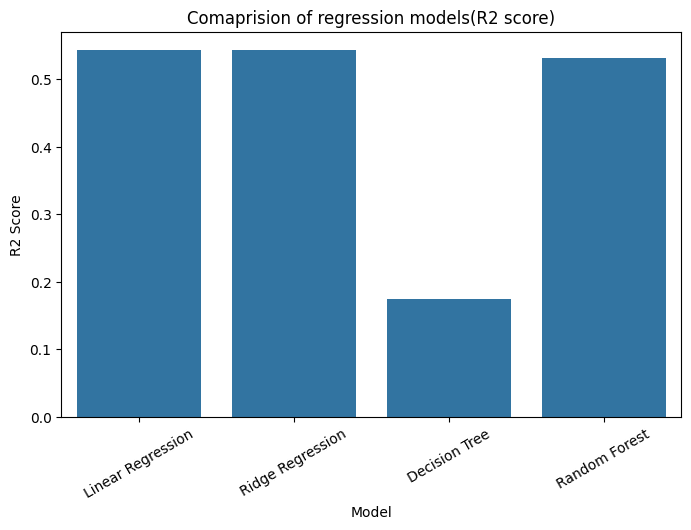

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title('Comaprision of regression models(R2 score)')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=30)
plt.show()

In [30]:
dtr = DecisionTreeRegressor()
dtr.fit(X_train,Y_train)
y_pred = dtr.predict(X_test)
print("Decison Tree MSE:", mean_squared_error(Y_test, y_pred))
print("Decision Tree R2 Score:", r2_score(Y_test, y_pred))

Decison Tree MSE: 9.214114832535886
Decision Tree R2 Score: 0.14882807873855886


In [32]:
rdm = RandomForestRegressor()
rdm.fit(X_train,Y_train)
y_pred = rdm.predict(X_test)
print("Random Forest MSE:", mean_squared_error(Y_test, y_pred))
print("Random Forest R2 Score:", r2_score(Y_test, y_pred))

Random Forest MSE: 4.945304306220096
Random Forest R2 Score: 0.5431678198013772


PREDECTING ABALONE AGE


In [34]:
def prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight):
    features = np.array([[Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight]])
    pred = dtr.predict(features).reshape(1, -1)
    return pred[0]

In [35]:
Sex = 2
Length = 0.6
Diameter = 0.45
Height = 0.15
Whole_weight = 1.2
Shucked_weight = 0.6
Viscera_weight = 0.3
Shell_weight = 0.4

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [12.]


In [41]:
Sex = 4
Length = 0.3
Diameter = 0.35
Height = 0.05
Whole_weight = 1.5
Shucked_weight = 0.2
Viscera_weight = 0.1
Shell_weight = 0.6

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [20.]


In [42]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)